## 📂 About Dataset

The **Sample Superstore dataset** is a retail sales dataset containing information about orders, customers, products, locations, sales, and other business-related details.

The dataset is used to practice **data cleaning, duplicate detection, exploratory data analysis, and business analytics**.

### 📊 Dataset Details

| Attribute         | Details           |
| ----------------- | ----------------- |
| Dataset Name      | Sample Superstore |
| File Format       | CSV               |
| Total Records     | 9,994             |
| Total Columns     | 13                |
| Duplicate Records | 17                |
| Cleaned Records   | 9,977             |
| Duplicate Rate    | 0.17%             |

### 🗂️ Main Information Covered

The dataset contains information related to:

* 🧾 **Orders** — Order and transaction details
* 👤 **Customers** — Customer-related information
* 📦 **Products** — Product and category details
* 📍 **Locations** — City, state, region, and postal information
* 💰 **Sales** — Sales-related values
* 🏷️ **Categories** — Product categories and sub-categories
* 🚚 **Shipping** — Shipping and order-related details

### 🎯 Dataset Purpose

This dataset is useful for:

* Identifying duplicate records
* Data cleaning and preprocessing
* Exploratory Data Analysis (EDA)
* Sales analysis
* Customer analysis
* Product performance analysis
* Regional analysis
* Business intelligence and reporting

For this project, the primary purpose of the dataset is to **identify, document, and remove exact duplicate records while maintaining an audit trail of the cleaning process**.


In [1]:
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical calculations

import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns            # Statistical data visualization

from scipy import stats       # Statistical analysis

import warnings               # Handle warning messages
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("SampleSuperstore.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9994
Number of columns: 13


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [7]:
duplicate_count = df.duplicated().sum()

print("Total duplicate records:", duplicate_count)

Total duplicate records: 17


In [8]:
duplicates = df[df.duplicated(keep=False)]

duplicates

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
568,Standard Class,Corporate,United States,Seattle,Washington,98105,West,Office Supplies,Paper,19.440,3,0.0,9.3312
591,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
935,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
1186,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
1479,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416
2803,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
2807,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
2836,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
3127,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864


In [9]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Rows belonging to duplicate groups:", len(duplicate_rows))

Rows belonging to duplicate groups: 34


In [10]:
duplicate_groups = duplicates.drop_duplicates()

print("Number of duplicate groups:", len(duplicate_groups))

Number of duplicate groups: 17


In [11]:
duplicate_report = duplicates.copy()

duplicate_report["Original_Row_Number"] = duplicate_report.index + 2

duplicate_report

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Original_Row_Number
568,Standard Class,Corporate,United States,Seattle,Washington,98105,West,Office Supplies,Paper,19.440,3,0.0,9.3312,570
591,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288,593
935,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432,937
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432,952
1186,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416,1188
1479,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416,1481
2803,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780,2805
2807,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208,2809
2836,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312,2838
3127,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864,3129


In [12]:
if "Order ID" in df.columns:
    
    order_id_duplicates = df[
        df["Order ID"].duplicated(keep=False)
    ]
    
    print("Duplicate Order IDs:")
    print(order_id_duplicates)

In [13]:
if "Order ID" in df.columns:
    
    print(
        "Number of duplicate Order IDs:",
        df["Order ID"].duplicated().sum()
    )

In [14]:
if "Product ID" in df.columns:
    
    product_id_duplicates = df[
        df["Product ID"].duplicated(keep=False)
    ]
    
    print("Duplicate Product IDs:")
    print(product_id_duplicates)

In [15]:
if "Customer ID" in df.columns:
    
    customer_id_duplicates = df[
        df["Customer ID"].duplicated(keep=False)
    ]
    
    print("Duplicate Customer IDs:")
    print(customer_id_duplicates)

In [18]:
duplicate_percentage = (
    df.duplicated().sum() / len(df)
) * 100

print(
    f"Duplicate percentage: {duplicate_percentage:.3f}%"
)

Duplicate percentage: 0.170%


In [19]:
cleaned_df = df.drop_duplicates(keep="first")

print("Original rows:", len(df))
print("Cleaned rows:", len(cleaned_df))

Original rows: 9994
Cleaned rows: 9977


In [20]:
removed_records = len(df) - len(cleaned_df)

print("Duplicate records removed:", removed_records)

Duplicate records removed: 17


In [21]:
remaining_duplicates = cleaned_df.duplicated().sum()

print(
    "Remaining duplicates:",
    remaining_duplicates
)

Remaining duplicates: 0


In [22]:
print("Cleaned dataset shape:", cleaned_df.shape)

Cleaned dataset shape: (9977, 13)


In [23]:
duplicate_report = df[
    df.duplicated(keep=False)
].copy()

duplicate_report["Original_Row_Number"] = (
    duplicate_report.index + 2
)

duplicate_report.to_csv(
    "SampleSuperstore_Duplicate_Report.csv",
    index=False
)

print("Duplicate report saved successfully!")

Duplicate report saved successfully!


In [24]:
cleaned_df.to_csv(
    "SampleSuperstore_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [25]:
audit_note = pd.DataFrame({
    
    "Audit Item": [
        "Original Records",
        "Number of Columns",
        "Exact Duplicate Records",
        "Duplicate Groups",
        "Duplicate Percentage",
        "Records Removed",
        "Cleaned Records",
        "Remaining Duplicates",
        "Duplicate Detection Rule",
        "Cleaning Rule"
    ],
    
    "Result": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        len(duplicate_groups),
        f"{duplicate_percentage:.3f}%",
        len(df) - len(cleaned_df),
        len(cleaned_df),
        cleaned_df.duplicated().sum(),
        "All columns matched exactly",
        "Kept first occurrence and removed later duplicate copies"
    ]
})

audit_note

,Audit Item,Result
0,Original Records,9994
1,Number of Columns,13
2,Exact Duplicate Records,17
3,Duplicate Groups,17
4,Duplicate Percentage,0.170%
5,Records Removed,17
6,Cleaned Records,9977
7,Remaining Duplicates,0
8,Duplicate Detection Rule,All columns matched exactly
9,Cleaning Rule,Kept first occurrence and removed later duplic...


In [26]:
print("========================================")
print("       DUPLICATE ANALYSIS SUMMARY")
print("========================================")

print("Original Records     :", len(df))
print("Columns              :", df.shape[1])
print("Duplicate Groups     :", len(duplicate_groups))
print("Duplicate Records    :", df.duplicated().sum())
print(
    "Duplicate Percentage :",
    f"{duplicate_percentage:.3f}%"
)
print(
    "Records Removed      :",
    len(df) - len(cleaned_df)
)
print("Cleaned Records      :", len(cleaned_df))
print(
    "Remaining Duplicates :",
    cleaned_df.duplicated().sum()
)

       DUPLICATE ANALYSIS SUMMARY
Original Records     : 9994
Columns              : 13
Duplicate Groups     : 17
Duplicate Records    : 17
Duplicate Percentage : 0.170%
Records Removed      : 17
Cleaned Records      : 9977
Remaining Duplicates : 0


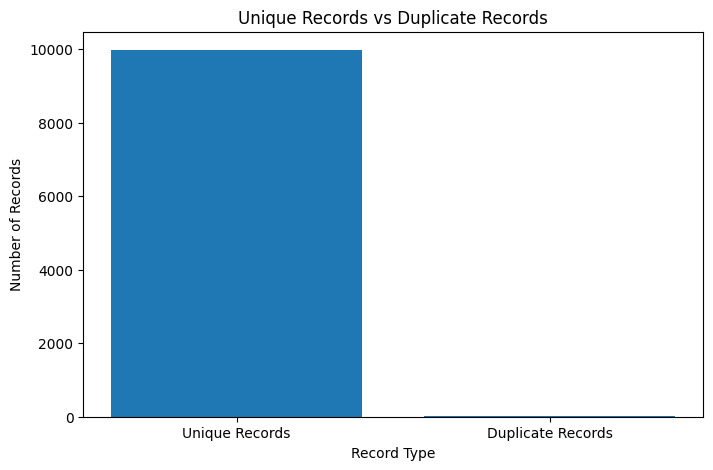

In [28]:



# Count duplicate records
duplicate_count = df.duplicated().sum()

# Count unique/non-duplicate records after keeping first occurrence
unique_count = len(df) - duplicate_count

# Data for graph
labels = ["Unique Records", "Duplicate Records"]
values = [unique_count, duplicate_count]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.title("Unique Records vs Duplicate Records")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.show()

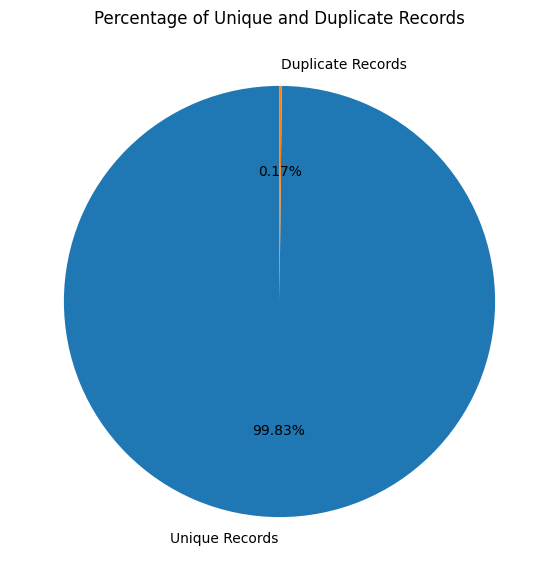

In [29]:

duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

labels = ["Unique Records", "Duplicate Records"]
values = [unique_count, duplicate_count]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Percentage of Unique and Duplicate Records")

plt.show()

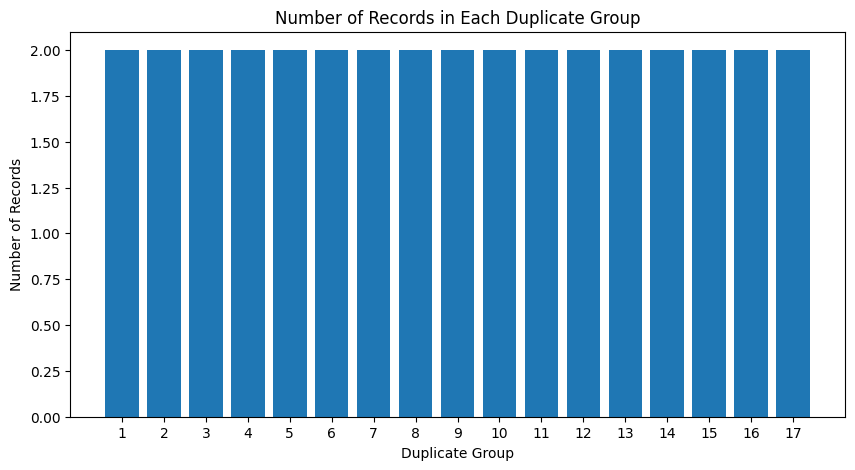

In [30]:
# Find all duplicate rows
duplicates = df[df.duplicated(keep=False)].copy()

# Create duplicate groups
duplicates["Duplicate_Group"] = (
    duplicates.groupby(list(df.columns), dropna=False)
    .ngroup() + 1
)

# Count records in each group
group_counts = duplicates["Duplicate_Group"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    group_counts.index.astype(str),
    group_counts.values
)

plt.title("Number of Records in Each Duplicate Group")
plt.xlabel("Duplicate Group")
plt.ylabel("Number of Records")

plt.show()

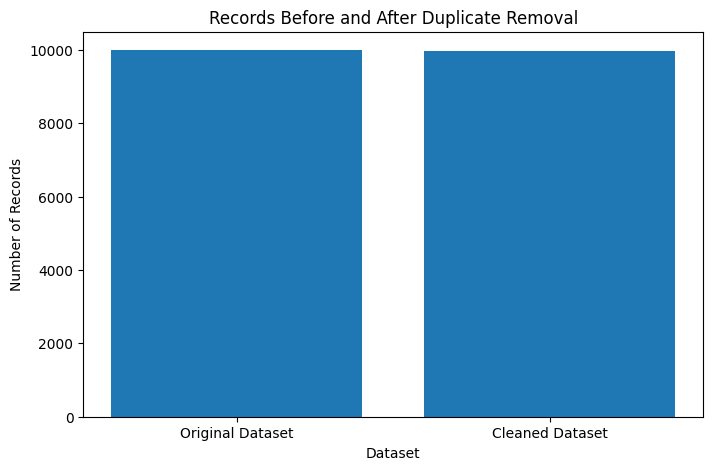

In [31]:
# Remove exact duplicates
cleaned_df = df.drop_duplicates(keep="first")

labels = ["Original Dataset", "Cleaned Dataset"]
values = [len(df), len(cleaned_df)]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Records Before and After Duplicate Removal")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")

plt.show()

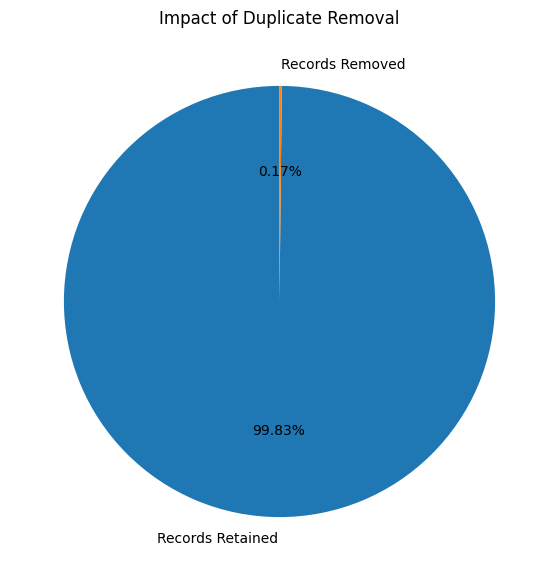

In [32]:
removed = len(df) - len(cleaned_df)
remaining = len(cleaned_df)

labels = ["Records Retained", "Records Removed"]
values = [remaining, removed]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Impact of Duplicate Removal")

plt.show()

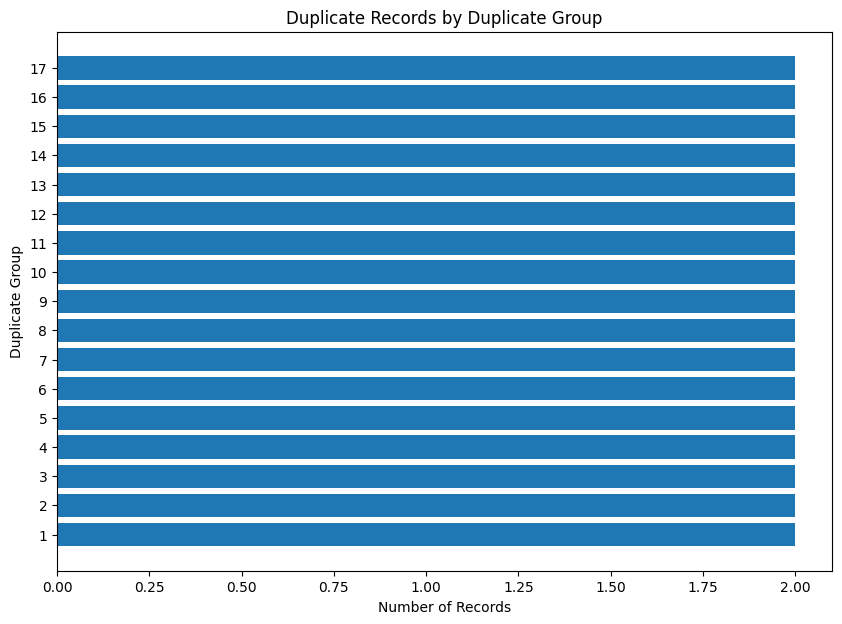

In [33]:
plt.figure(figsize=(10, 7))

plt.barh(
    group_counts.index.astype(str),
    group_counts.values
)

plt.title("Duplicate Records by Duplicate Group")
plt.xlabel("Number of Records")
plt.ylabel("Duplicate Group")

plt.show()

In [34]:
print("========== GRAPH ANALYSIS ==========")

print("Total Records:", len(df))
print("Unique Records:", len(df) - df.duplicated().sum())
print("Duplicate Records:", df.duplicated().sum())

duplicate_percentage = (
    df.duplicated().sum() / len(df)
) * 100

print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

cleaned_df = df.drop_duplicates()

print("Records After Cleaning:", len(cleaned_df))
print("Records Removed:", len(df) - len(cleaned_df))

========== GRAPH ANALYSIS ==========
Total Records: 9994
Unique Records: 9977
Duplicate Records: 17
Duplicate Percentage: 0.17%
Records After Cleaning: 9977
Records Removed: 17


# Conclusion

The **Duplicate Record Check** was successfully performed on the Sample Superstore dataset. The dataset initially contained **9,994 records and 13 columns**. The analysis identified **17 exact duplicate records**, representing approximately **0.17%** of the total dataset.

The duplicate records were removed while keeping the first occurrence of each record. After cleaning, the dataset contained **9,977 records** with **no exact duplicate records remaining**.

The duplicate report and audit note were also created to document the duplicate detection and cleaning process. Overall, the dataset had a **very low level of duplication** and is now ready for further data analysis.
